<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/2_15_Matplotlib Scatter Plots.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## 🟨 Median Yearly Salary vs. Job Count (2.15.1)

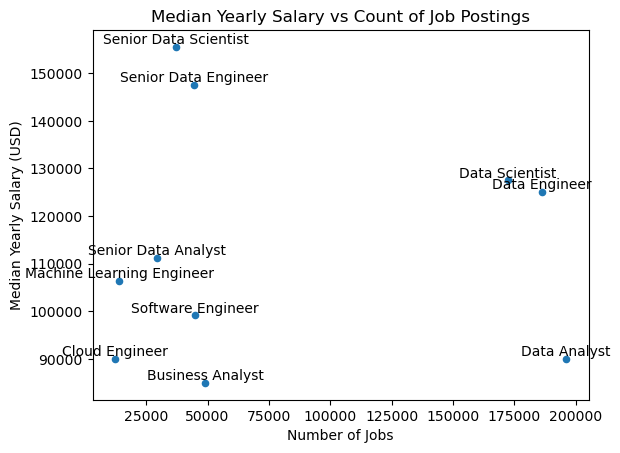

In [2]:
salary_stats = df.groupby('job_title_short')['salary_year_avg'].agg(['size', 'median'])
salary_stats.plot(kind='scatter', x = 'size', y='median')



for i, txt in enumerate(salary_stats.index):
    plt.text(salary_stats['size'].iloc[i], salary_stats['median'].iloc[i], txt, ha='center', va='bottom')
plt.xlabel('Number of Jobs')
plt.ylabel('Median Yearly Salary (USD)')
plt.title('Median Yearly Salary vs Count of Job Postings')
plt.show()

---

## 🟨 Top 7 Countries by Median Yearly Salary vs Job Count  (2.15.2)

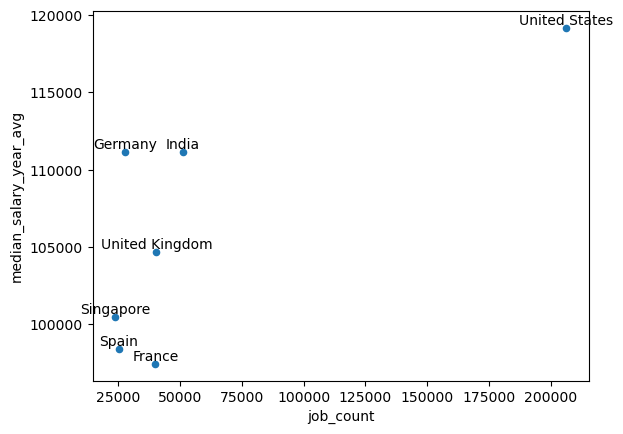

In [3]:
country_stats = df.groupby('job_country').agg(
   median_salary_year_avg=('salary_year_avg', 'median'),
   job_count=('job_country', 'count')
).dropna()
top_countries = country_stats.sort_values(by='job_count', ascending=False).head(7)
top_countries.plot(kind='scatter', x = 'job_count', y='median_salary_year_avg')

for i, txt in enumerate(top_countries.index):
    plt.text(top_countries['job_count'].iloc[i], top_countries['median_salary_year_avg'].iloc[i], txt, ha='center', va='bottom')


plt.show()

---

## 🟥 Average Yearly Salary vs. Job Count for Top Roles by Schedule Type (2.15.3)

In [ ]:
# Code Needed
target_job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

df_title_usa = df[(df['job_title_short'].isin(target_job_titles)) & (df['job_country'] == 'United States') & (df['job_schedule_type'].isin(['Full-time','Contractor']))]
df_title_usa = df_title_usa[df_title_usa['salary_year_avg'].notna()]



stats = df_title_usa.groupby(['job_schedule_type', 'job_title_short']).agg(
   mean_salary_year_avg=('salary_year_avg', 'mean'),
   job_count=('job_title_short', 'count')
).dropna()

stats.reset_index(inplace=True)

stats['job_title_type'] = stats['job_title_short'] + ' - ' + stats['job_schedule_type']

for job_title_type in stats['job_title_type'].unique():
   subset = stats[stats['job_title_type'] == job_title_type]
   plt.scatter(subset['job_count'], subset['mean_salary_year_avg'], label=job_title_type)


plt.title('Average Yearly Salary vs. Job Count for Top Roles by Schedule Type')

plt.legend()
plt.xlabel("Job Count")
plt.ylabel("Median Annual Salary")

plt.show()


,job_schedule_type,job_title_short,mean_salary_year_avg,job_count
0,Contractor,Data Analyst,87027.197142,111
1,Contractor,Data Engineer,117772.326225,74
2,Contractor,Data Scientist,118568.074155,61
3,Full-time,Data Analyst,95072.545202,4097
4,Full-time,Data Engineer,133804.432239,2759
5,Full-time,Data Scientist,140848.379828,4325


---